In [2]:
from pathlib import Path
import os, json, math, re, shutil, itertools, time
import torch
from typing import List, Dict, Any


NEPTUNE_PROJECT = os.environ.get("NEPTUNE_PROJECT", "fedllm/fedllm")
import neptune
token = 'eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiIzZDNlMTFjYi0wMzQ4LTRmMDUtOTk4NC0wZjBlOGU5NGExMmYifQ=='

def resolve_one_run(run_id: str, args=None):
    print("here")
    RUNS_TO_PROCESS = []
    run = neptune.init_run(project=NEPTUNE_PROJECT, with_id=run_id, api_token=token, mode="read-only")
    print("done")
    resolved = None
    for field in [
        "parameters/total_output_dir",
        "parameters/script_args/output_dir",
    ]:
        try:
            v = run[field].fetch()
            if isinstance(v, str) and v:
                resolved = v
                break
        except Exception:
            pass
    try:
        model_name_or_path = run["parameters/script_args/model_name_or_path"].fetch()
        num_rounds = run['parameters/fed_args/num_rounds'].fetch()
        sample_clients = run['parameters/fed_args/sample_clients'].fetch()
        template = run['parameters/script_args/template'].fetch()
        
    except Exception:
        model_name_or_path = None

    
    safelora_original_saved_path = None

    

    # Fallback: best-effort local guess by run id name
    if not resolved:
        from pathlib import Path
        def _guess_dir_from_run_id(rid: str) -> str | None:
            candidates = [Path("./outputs"), Path(".")]
            for root in candidates:
                if (root / rid).is_dir() and (root / rid / "lora_updates").is_dir():
                    return str(root / rid)
                for p in root.glob(f"**/{rid}"):
                    if p.is_dir() and (p / "lora_updates").is_dir():
                        return str(p)
            return None
        guess = _guess_dir_from_run_id(run_id)
        if guess:
            resolved = guess
            print(f"[Neptune] Guessed BASE_OUTPUT_DIR for {run_id}: {resolved}")
    print(resolved, model_name_or_path, num_rounds, sample_clients)
    # if resolved:
    run_data = {
        "run_id": run_id,
        "base_output_dir": resolved,
        "model_name_or_path": model_name_or_path,
        "num_rounds": num_rounds,
        "sample_clients": sample_clients,
        "template": template,
        "safelora_original_saved_path": safelora_original_saved_path,
    }
    # else:
    #     print(f"[WARN] Could not resolve output_dir for run {run_id}; skipping.")
    # run.stop()
    return run_data

In [5]:
run_ids = [450, 444, 445, 447, 446]
run_ids = ['FED-'+str(rid) for rid in run_ids]
order = ["squad", "pubmed", "trivia", "metamath", "pubmed + trivia"]
RUNS_TO_PROCESS = [resolve_one_run(rid) for rid in run_ids]

here
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/fedllm/fedllm/e/FED-450
done
/shared/rc/llm-degredation/fedllm/barebones/squad_v27_BeaverTails3_500_eval_filter_c10s10_i10_b16a1_l512_r32a64_20260127171907 meta-llama/Llama-2-7b-chat-hf 30 10
here
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/fedllm/fedllm/e/FED-444
done
/shared/rc/llm-degredation/fedllm/barebones/PubMedQA7_BeaverTails3_500_eval_filter_c10s10_i5_b16a1_l512_r32a64_20260127162414 meta-llama/Llama-2-7b-chat-hf 30 10
here
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/fedllm/fedllm/e/FED-445
done
/shared/rc/llm-degredation/fedllm/barebones/triviaqa7_BeaverTails3_500_eval_filter_c10s10_i5_b16a1_l512_r32a64_20260127163621 meta-llama/Llama-2-7b-chat-hf 30 10
here
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/fedllm/fedllm/e/FED-447
done
/shared/rc/llm-degredation/fedllm/barebones/metamathq

In [ ]:
import os
import json
for run in RUNS_TO_PROCESS:
    dir = run['base_output_dir']
    for round in range(1, run['num_rounds']+1):
        detection_file = os.path.join(dir, f'asr_rates_round_{round}.json')
        data = json.load(open(detection_file, 'r'))
        print(data['clients'])


In [1]:

import os
import json


# dir1 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_c7s7_i10_b16a1_l512_r32a64_20260227002424/safelora_rescale_projected_keep_residual'
# dir2 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_layerwise_c7s7_i10_b16a1_l512_r32a64_20260227010715/safelora_rescale_projected_keep_residual'
# dir3 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260227075928/safelora_rescale_projected_keep_residual'


# dir1 = '/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_c7s7_i10_b16a1_l512_r32a64_20260223115432/safelora_rescale_projected_keep_residual'
# dir2 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260301182033/safelora_rescale_projected_keep_residual'
# dir3 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260301182032/safelora_rescale_projected_keep_residual'

# dir1 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_c7s7_i10_b16a1_l512_r32a64_20260302005759/safelora_rescale_projected_keep_residual'
# dir2 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_layerwise_c7s7_i10_b16a1_l512_r32a64_20260302163738/safelora_rescale_projected_keep_residual'
# dir3 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260301190953/safelora_rescale_projected_keep_residual'

# dir1 = '/scratch/ps9044_copy/newsetting/PubMedQA_medQA_emrqa_cord19_expguardtrain3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_c7s7_i10_b16a1_l512_r32a64_20260314060320'
# dir2 = '/scratch/ps9044_copy/newsetting/PubMedQA_medQA_emrqa_cord19_expguardtrain3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_c7s7_i10_b16a1_l512_r32a64_20260314071026'
# dir3 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_expguardtrain3_500_safe_lora_c10s10_i10_b16a1_l512_r32a64_20260314095519'

dir1 = '/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_500_safe_lora_c10s10_i10_b16a1_l512_r32a64_20260212170509'
# dir1 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260301181317/safelora_rescale_projected_keep_residual' #0.5
# dir2 ='/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260301182033/safelora_rescale_projected_keep_residual' #1.5
# dir3 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260301181316/safelora_rescale_projected_keep_residual' #2.0
# dir3 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260302161456/safelora_rescale_projected_keep_residual' #10.0
# dir3 = '/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_c7s10_i10_b16a1_l512_r32a64_20260218140242/safelora'

dirs= [dir1, dir1, dir1]
# dirs= [dir3, dir3, dir3]

# /scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260301181317
# /scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260301182033
# /scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260301181316



for dir in dirs:
    true_benign = [0, 1, 2, 3, 4, 5, 6]
    true_malicious = [7, 8, 9]
    # try:
    for round in range(30):
        # name = f'round_{round}_evalfilter_gmm.json'
        name = f'safelora/round_{round}.json'
        detection_file = os.path.join(dir, name)
        data = json.load(open(detection_file, 'r'))
        missed_benign = [c for c in true_benign if c not in data['selected_clients']]
        missed_malicious = [c for c in true_malicious if c in data['selected_clients']]
        # if missed_malicious:
        #     print(f"Round {round}:  Missed malicious: {missed_malicious}")
        if missed_benign:
            print(f"Round {round}:  Missed benign: {missed_benign}")
    # except:
    #     print(round)
    #     pass

    # try:
    for round in range(30):
        # name = f'round_{round}_evalfilter_gmm.json'
        name = f'safelora/round_{round}.json'
        detection_file = os.path.join(dir, name)
        data = json.load(open(detection_file, 'r'))
        missed_benign = [c for c in true_benign if c not in data['selected_clients']]
        missed_malicious = [c for c in true_malicious if c in data['selected_clients']]
        if missed_malicious:
            print(f"Round {round}:  Missed malicious: {missed_malicious}")
    # except:
    #     print(round)
    #     pass

    print()
    # if missed_malicious:
    #     print(f"Round {round}:  Missed benign: {missed_benign}")
    # print(f"Round {round}:", data['selected_clients'])

saved: /scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260301181317/safelora_rescale_projected_keep_residual/misdetection_stats.png
saved: /scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260301182033/safelora_rescale_projected_keep_residual/misdetection_stats.png
saved: /scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260302161456/safelora_rescale_projected_keep_residual/misdetection_stats.png


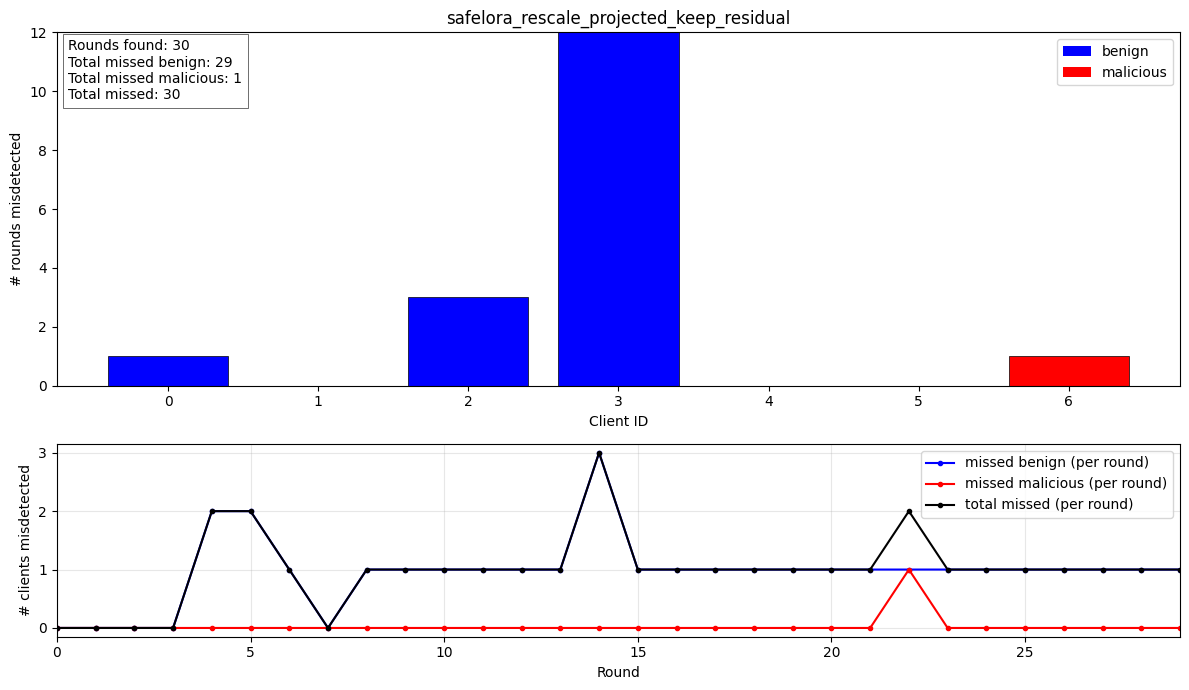

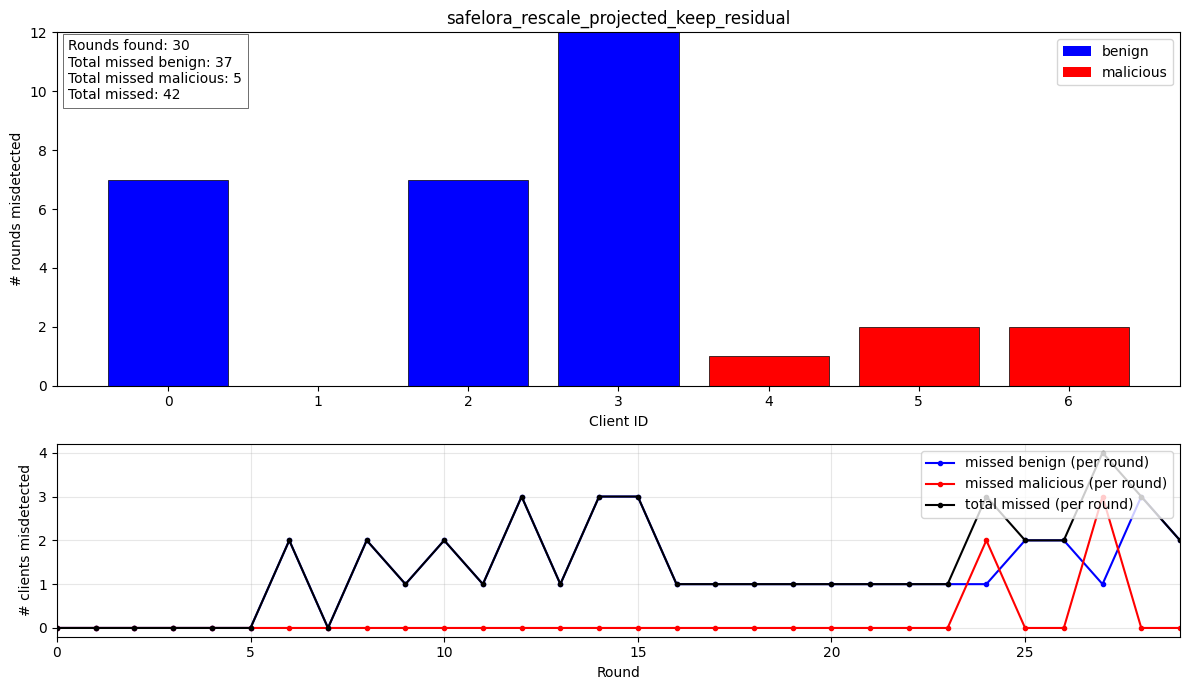

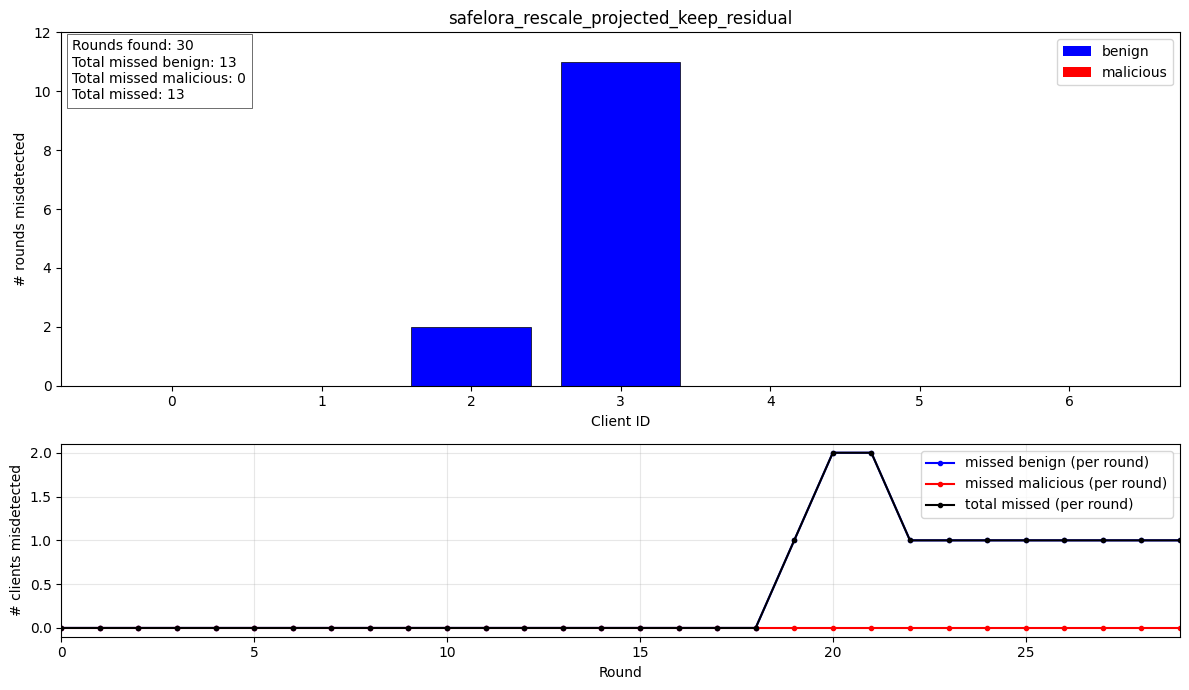

In [12]:
import os, json
import numpy as np
import matplotlib.pyplot as plt

def _to_int_list(x):
    if x is None:
        return []
    out = []
    for v in x:
        try:
            out.append(int(v))
        except Exception:
            # ignore weird entries rather than crashing
            pass
    return out

def collect_misdetection_stats(
    run_dir: str,
    true_benign=(0, 1, 2, 3),
    true_malicious=(4, 5, 6),
    n_rounds=30,
    filename_template="round_{round}.json",   # change to "round_{round}_evalfilter_gmm.json" if needed
):
    true_benign = list(true_benign)
    true_malicious = list(true_malicious)
    all_clients = true_benign + true_malicious

    per_client_counts = {c: 0 for c in all_clients}

    missed_benign_per_round = np.full(n_rounds, np.nan, dtype=float)
    missed_malicious_per_round = np.full(n_rounds, np.nan, dtype=float)
    total_missed_per_round = np.full(n_rounds, np.nan, dtype=float)

    found_any = False

    for r in range(n_rounds):
        path = os.path.join(run_dir, filename_template.format(round=r))
        if not os.path.exists(path):
            continue

        found_any = True
        with open(path, "r") as f:
            data = json.load(f)

        selected = _to_int_list(data.get("selected_clients", []))

        # "missed benign" == benign NOT selected
        missed_benign = [c for c in true_benign if c not in selected]
        # "missed malicious" == malicious that slipped through (WAS selected)
        missed_malicious = [c for c in true_malicious if c in selected]

        for c in missed_benign:
            per_client_counts[c] += 1
        for c in missed_malicious:
            per_client_counts[c] += 1

        missed_benign_per_round[r] = len(missed_benign)
        missed_malicious_per_round[r] = len(missed_malicious)
        total_missed_per_round[r] = len(missed_benign) + len(missed_malicious)

    totals = {
        "total_missed_benign": int(np.nansum(missed_benign_per_round)),
        "total_missed_malicious": int(np.nansum(missed_malicious_per_round)),
        "total_missed": int(np.nansum(total_missed_per_round)),
        "rounds_found": int(np.sum(~np.isnan(total_missed_per_round))),
        "found_any": found_any,
    }

    return {
        "run_dir": run_dir,
        "true_benign": true_benign,
        "true_malicious": true_malicious,
        "all_clients": all_clients,
        "per_client_counts": per_client_counts,
        "missed_benign_per_round": missed_benign_per_round,
        "missed_malicious_per_round": missed_malicious_per_round,
        "total_missed_per_round": total_missed_per_round,
        "totals": totals,
    }

def plot_stats_for_dir(stats, save_path=None):
    run_dir = stats["run_dir"]
    benign = stats["true_benign"]
    malicious = stats["true_malicious"]
    clients = stats["all_clients"]
    counts = np.array([stats["per_client_counts"][c] for c in clients], dtype=float)

    colors = [("blue" if c in benign else "red") for c in clients]

    rounds = np.arange(len(stats["total_missed_per_round"]))
    mb = stats["missed_benign_per_round"]
    mm = stats["missed_malicious_per_round"]
    tm = stats["total_missed_per_round"]

    fig, (ax_bar, ax_line) = plt.subplots(
        2, 1, figsize=(12, 7),
        gridspec_kw={"height_ratios": [2.2, 1.2]}
    )

    # --- bar plot: per-client misdetection counts ---
    ax_bar.bar(clients, counts, color=colors, edgecolor="black", linewidth=0.5)
    ax_bar.set_xlabel("Client ID")
    ax_bar.set_ylabel("# rounds misdetected")
    ax_bar.set_title(os.path.basename(run_dir) or run_dir)
    ax_bar.set_ylim(0, 12)

    # simple legend
    from matplotlib.patches import Patch
    ax_bar.legend(
        handles=[Patch(facecolor="blue", label="benign"), Patch(facecolor="red", label="malicious")],
        loc="upper right"
    )

    # totals text
    t = stats["totals"]
    ax_bar.text(
        0.01, 0.98,
        f"Rounds found: {t['rounds_found']}\n"
        f"Total missed benign: {t['total_missed_benign']}\n"
        f"Total missed malicious: {t['total_missed_malicious']}\n"
        f"Total missed: {t['total_missed']}",
        transform=ax_bar.transAxes,
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black", linewidth=0.5)
    )

    # --- line plot: per-round totals (3 lines) ---
    ax_line.plot(rounds, mb, label="missed benign (per round)", color="blue", marker="o", markersize=3)
    ax_line.plot(rounds, mm, label="missed malicious (per round)", color="red", marker="o", markersize=3)
    ax_line.plot(rounds, tm, label="total missed (per round)", color="black", marker="o", markersize=3)
    ax_line.set_xlabel("Round")
    ax_line.set_ylabel("# clients misdetected")
    ax_line.set_xlim(0, len(rounds) - 1)
    ax_line.legend(loc="upper right")
    ax_line.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    return fig

# -------------------- usage --------------------
# dir1 = '/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_c7s7_i10_b16a1_l512_r32a64_20260223115432/safelora_rescale_projected_keep_residual'
# dir2 = '/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_layerwise_c7s7_i10_b16a1_l512_r32a64_20260225150028/safelora_rescale_projected_keep_residual'
# dir3 = '/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260225143729/safelora_rescale_projected_keep_residual'

# dir1 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_c7s7_i10_b16a1_l512_r32a64_20260227002424/safelora_rescale_projected_keep_residual'
# dir2 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_layerwise_c7s7_i10_b16a1_l512_r32a64_20260227010715/safelora_rescale_projected_keep_residual'
# dir3 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260227075928/safelora_rescale_projected_keep_residual'


# another seed
# dir1 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_c7s7_i10_b16a1_l512_r32a64_20260302005759/safelora_rescale_projected_keep_residual'
# dir2 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_layerwise_c7s7_i10_b16a1_l512_r32a64_20260302163738/safelora_rescale_projected_keep_residual'
# dir3 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260301190953/safelora_rescale_projected_keep_residual'

dir1 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260301181317/safelora_rescale_projected_keep_residual' #0.5
dir2 ='/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260301182033/safelora_rescale_projected_keep_residual' #1.5
dir3 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260301181316/safelora_rescale_projected_keep_residual' #2.0
dir3 = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260302161456/safelora_rescale_projected_keep_residual' #10
dirs = [dir1, dir2, dir3]

for d in dirs:
    stats = collect_misdetection_stats(
        d,
        true_benign=[0, 1, 2, 3],
        true_malicious=[4, 5, 6],
        n_rounds=30,
        filename_template="round_{round}.json",
    )
    if not stats["totals"]["found_any"]:
        print(f"[warn] no round files found in: {d}")
        continue

    save_png = os.path.join(d, "misdetection_stats.png")
    plot_stats_for_dir(stats, save_path=save_png)
    print(f"saved: {save_png}")

plt.show()

In [2]:
# dir = '/home/ps9044/FedLLM-Attack/output/evalfilter/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[7][rajpurkar/squad_v2]_malicious[3][PKU-Alignment/BeaverTails]_Steps[10]_Clients[10]_ISA[False]'
# dir = '/home/ps9044/FedLLM-Attack/output/evalfilter/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[7][qiaojin/PubMedQA]_malicious[3][PKU-Alignment/BeaverTails]_Steps[5]_Clients[10]_ISA[False]'
# dir = '/home/ps9044/FedLLM-Attack/output/evalfilter/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[7][triviaqa]_malicious[3][PKU-Alignment/BeaverTails]_Steps[5]_Clients[10]_ISA[False]'

# dir = '/home/ps9044/FedLLM-Attack/output/evalfilter/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[3_3][qiaojin/PubMedQA_triviaqa]_malicious[3][PKU-Alignment/BeaverTails]_Steps[5]_Clients[10]_ISA[False]'
# dir = '/home/ps9044/FedLLM-Attack/output/evalfilter/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[7][metamathqa]_malicious[3][PKU-Alignment/BeaverTails]_Steps[10]_Clients[10]_ISA[False]'
# dir = '/home/ps9044/FedLLM-Attack/output/evalfilter/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[7][triviaqa]_malicious[3][PKU-Alignment/BeaverTails]_Steps[5]_Clients[10]_ISA[False]'
# dir = '/home/ps9044/FedLLM-Attack/output/evalfilter/meta-llama/Llama-2-7b-chat-hf/C10_N30_benign[3_3][qiaojin/PubMedQA_triviaqa]_malicious[3][PKU-Alignment/BeaverTails]_Steps[5]_Clients[10]_ISA[False]'
true_benign = [0, 1, 2, 3, 4, 5]
true_malicious = [6, 7, 8]
for round in range(30):
    detection_file = os.path.join(dir, f'round_{round}_evalfilter_gmm.json')
    data = json.load(open(detection_file, 'r'))
    missed_benign = [c for c in true_benign if c not in data['selected_clients']]
    missed_malicious = [c for c in true_malicious if c in data['selected_clients']]
    # if missed_malicious:
    #     print(f"Round {round}:  Missed malicious: {missed_malicious}")
    if missed_benign:
        print(f"Round {round}:  Missed benign: {missed_benign}")
    # print(f"Round {round}:", data['selected_clients'])

FileNotFoundError: [Errno 2] No such file or directory: '/shared/rc/llm-degredation/fedllm/barebones/metamathqa3_squad_v23_BeaverTails3_500_krum_c9s10_i10_b16a1_l512_r32a64_20260130234305/krum/round_0_evalfilter_gmm.json'

In [3]:
# dir = '/shared/rc/llm-degredation/fedllm/barebones/PubMedQA3_triviaqa3_BeaverTails3_500_safe_lora_c9s10_i5_b16a1_l512_r32a64_20260127204846/safelora/Steps[5]_Clients[10]_ISA[False]'
# dir = '/shared/rc/llm-degredation/fedllm/barebones/triviaqa7_BeaverTails3_500_safe_lora_c10s10_i5_b16a1_l512_r32a64_20260127171858/safelora/Steps[5]_Clients[10]_ISA[False]'
import os
import json
# dir = '/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_c7s7_i10_b16a1_l512_r32a64_20260223115432/safelora_rescale_projected_keep_residual'
# dir = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_c7s7_i10_b16a1_l512_r32a64_20260227002424/safelora_rescale_projected_keep_residual'
# dir = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_debug_keep5_c7s7_i10_b16a1_l512_r32a64_20260226125410'
# dir = '/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_mixture_analytical_c7s7_i10_b16a1_l512_r32a64_20260225143729/safelora_rescale_projected_keep_residual'
# dir = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails1_500_safe_lora_c8s8_i10_b16a1_l512_r32a64_20260227042436/safelora'
# dir = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails1_500_krum_c8s8_i10_b16a1_l512_r32a64_20260227035312/krum'
dir='/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_500_safe_lora_c10s10_i10_b16a1_l512_r32a64_20260212170509/safelora'
# dir = '/scratch/ps9044/newsetting/PubMedQA_medQA_emrqa_cord19_BeaverTails1_500_krum_c8s8_i10_b16a1_l512_r32a64_20260227035312/'
true_benign = [0, 1, 2, 3,]
true_malicious = [4,5, 6]
for round in range(30):
    detection_file = os.path.join(dir, f'round_{round}.json')
    # try:
    data = json.load(open(detection_file, 'r'))
    # except:
        # continue
    missed_benign = [c for c in true_benign if c not in data['selected_clients']]
    missed_malicious = [c for c in true_malicious if c in data['selected_clients']]
    if missed_malicious:
        print(f"Round {round}:  Missed malicious: {missed_malicious}")
    if missed_benign:
        print(f"Round {round}:  Missed benign: {missed_benign}")
    # print(f"Round {round}:", data['selected_clients'])

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_500_safe_lora_c10s10_i10_b16a1_l512_r32a64_20260212170509/safelora/round_0.json'

In [6]:
import os
import json
dir = '/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_1.00_1.00_1.00_1.00_0.50_0.50_0.50_200_safe_lora_c7s10_i10_b16a1_l512_r32a64_20260218140242/safelora'

true_benign = [0, 1, 2, 3, ]
true_malicious = [4, 5, 6]
for round in range(30):
    detection_file = os.path.join(dir, f'round_{round}.json')
    data = json.load(open(detection_file, 'r'))
    missed_benign = [c for c in true_benign if c not in data['selected_clients']]
    missed_malicious = [c for c in true_malicious if c in data['selected_clients']]
    if missed_malicious:
        print(f"Round {round}:  Missed malicious: {missed_malicious}")
    if missed_benign:
        print(f"Round {round}:  Missed benign: {missed_benign}")
    # print(f"Round {round}:", data['selected_clients'])

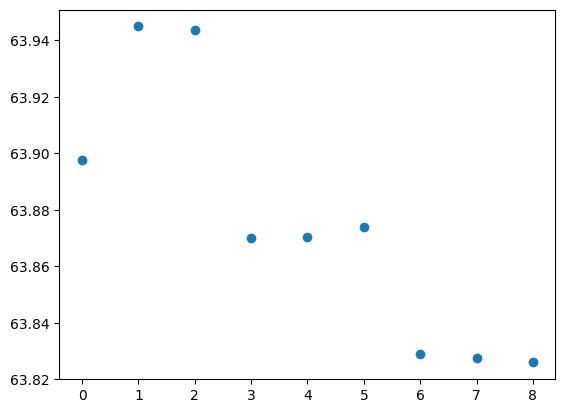

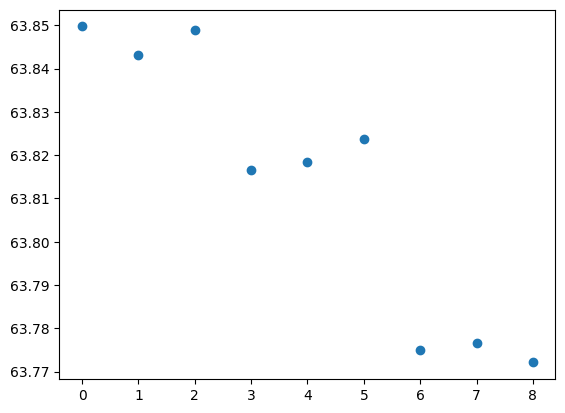

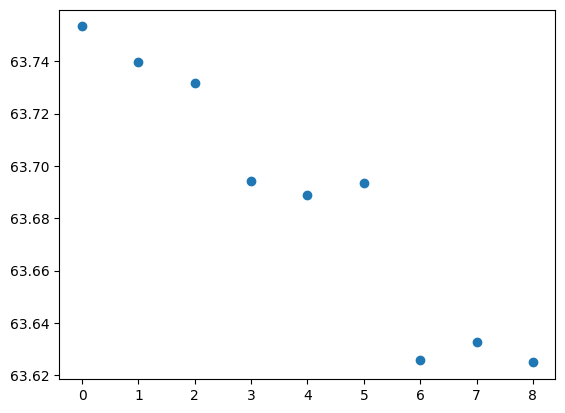

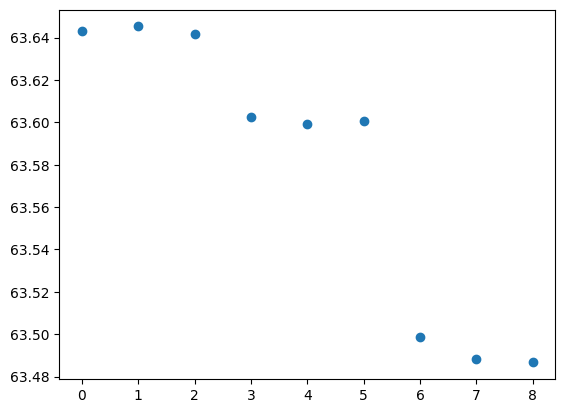

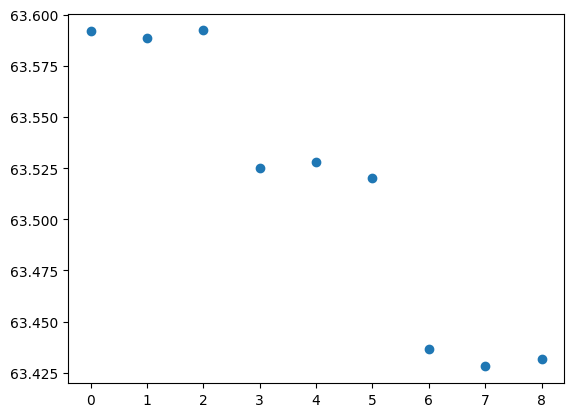

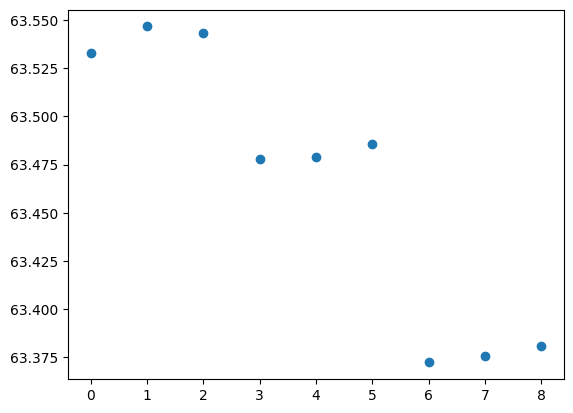

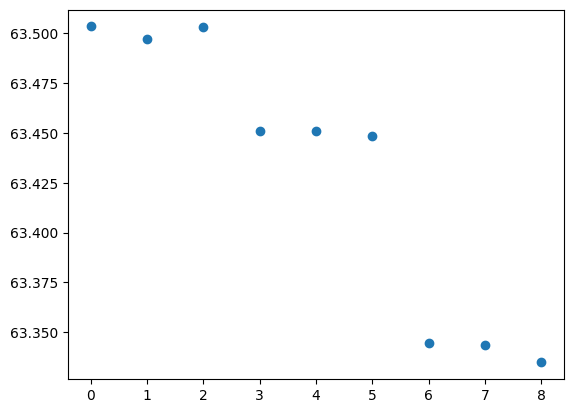

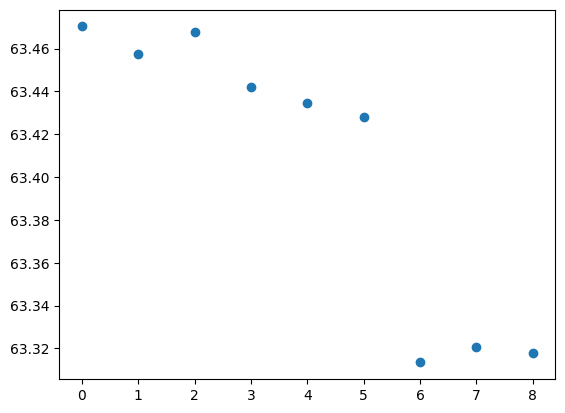

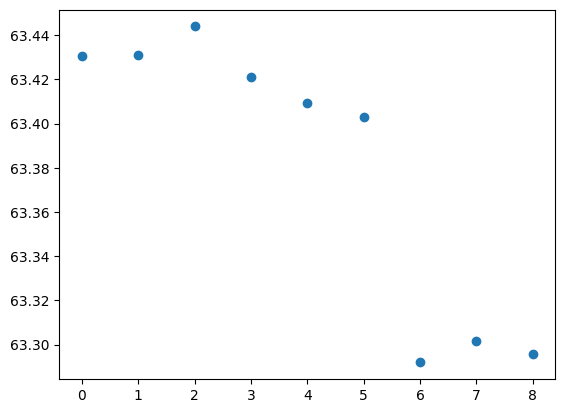

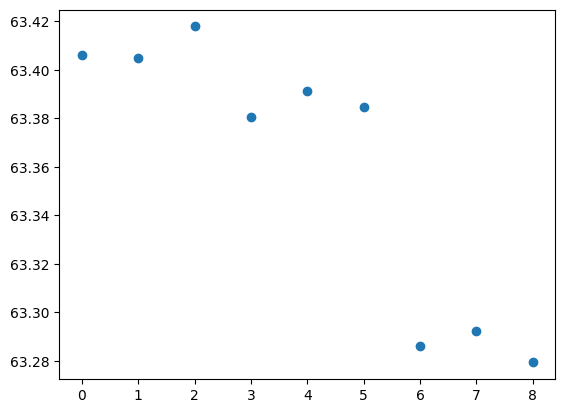

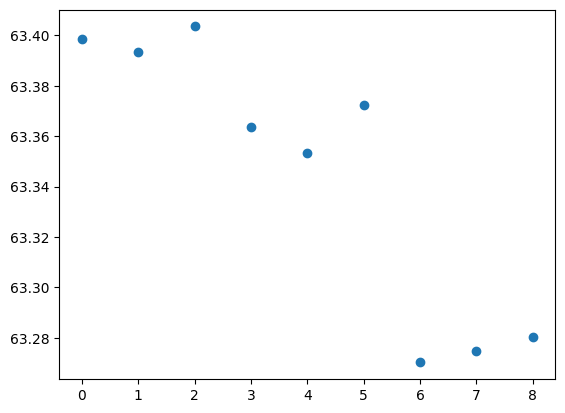

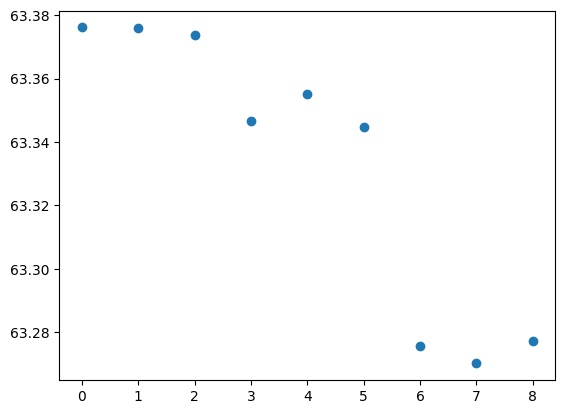

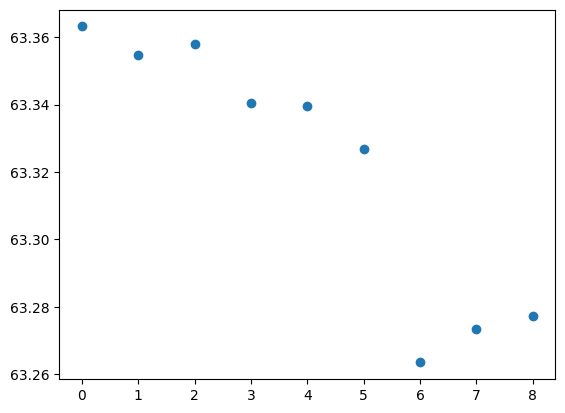

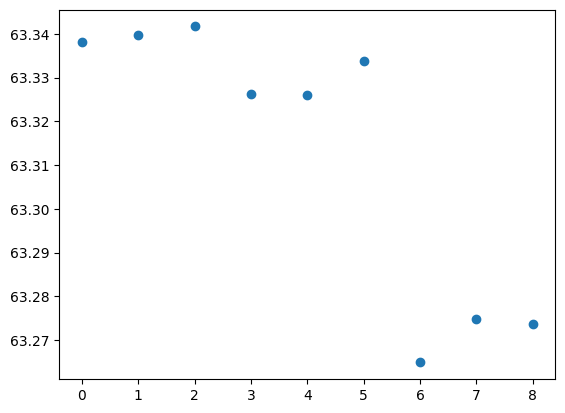

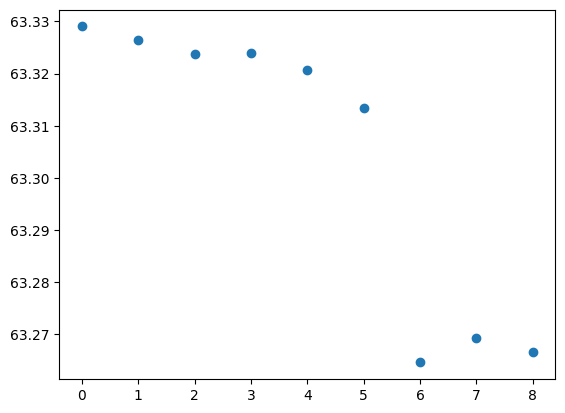

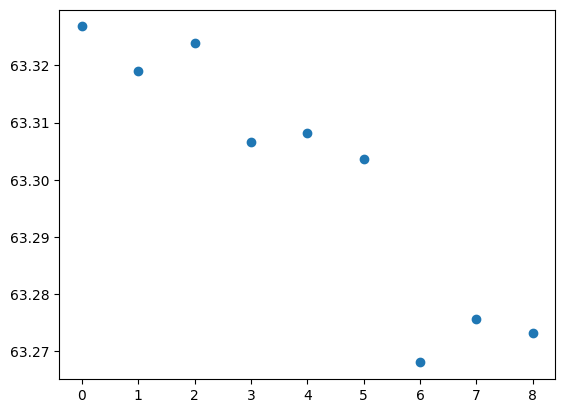

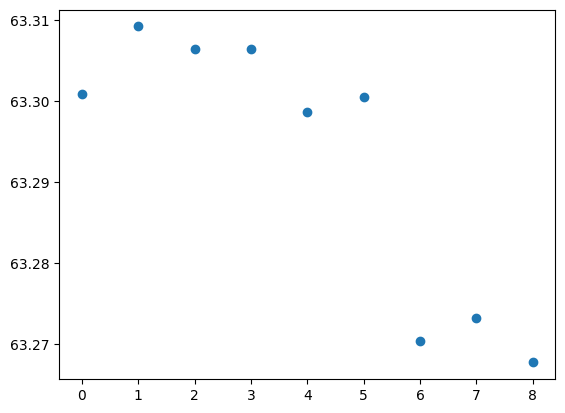

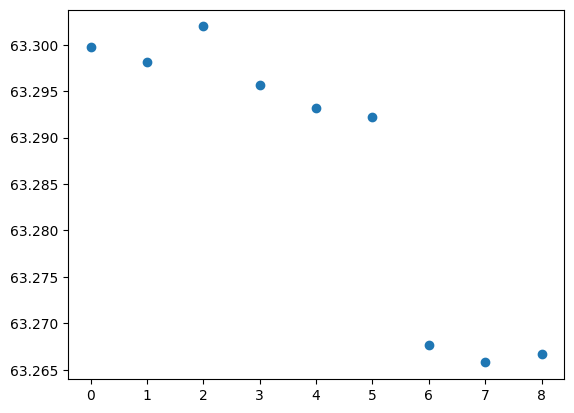

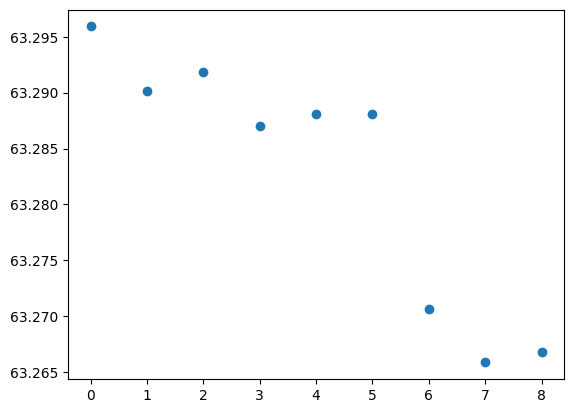

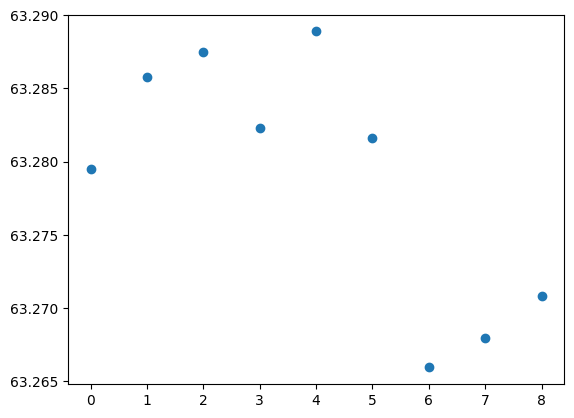

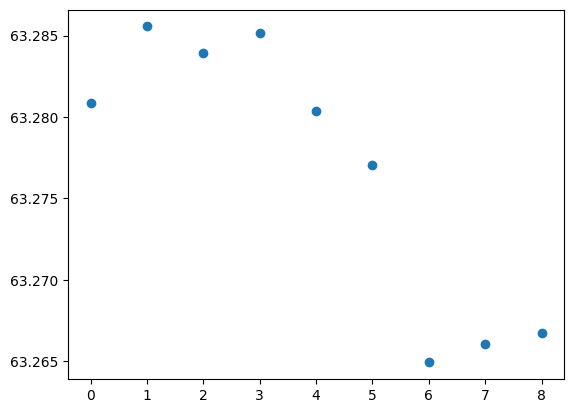

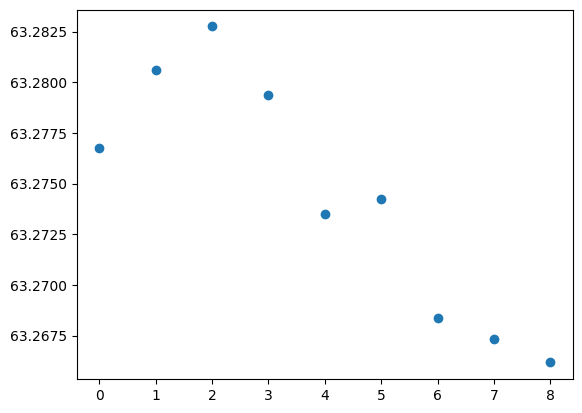

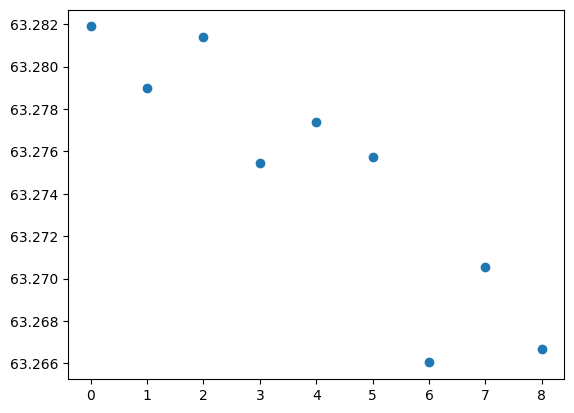

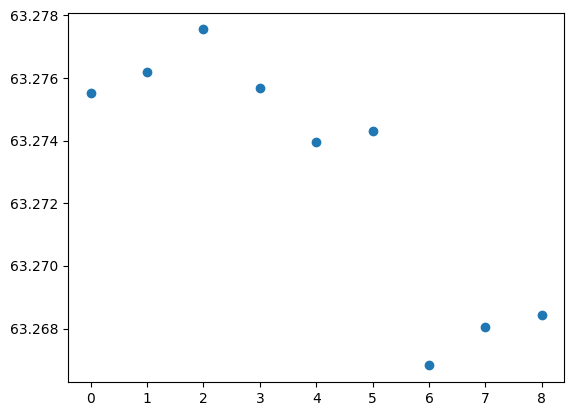

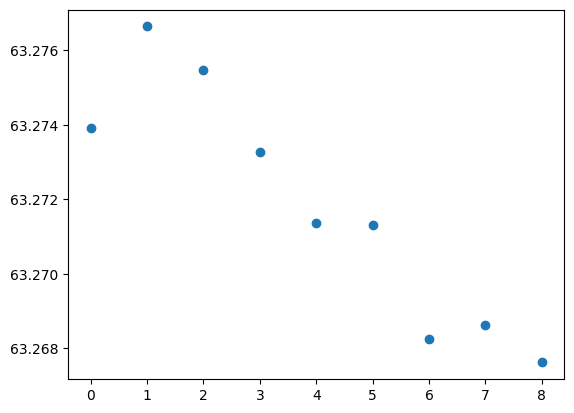

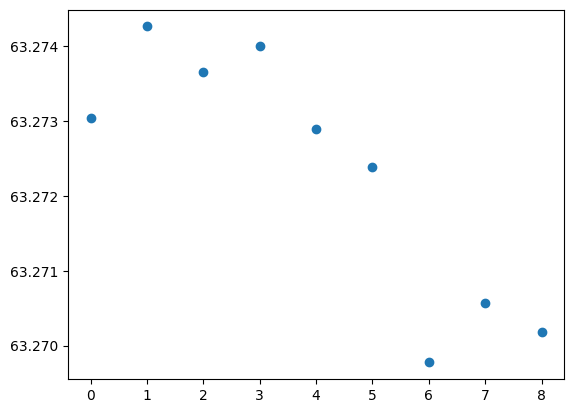

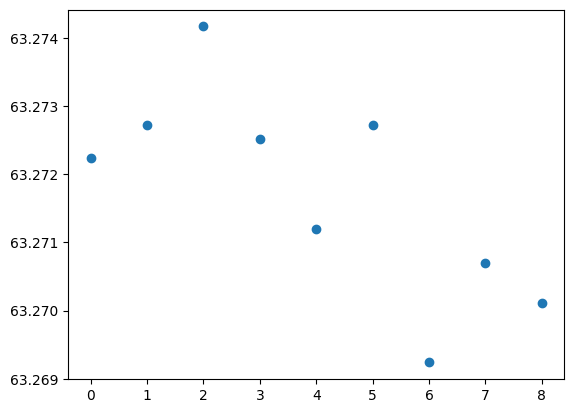

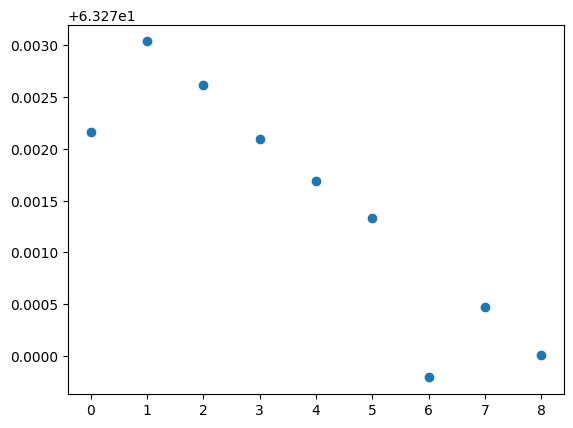

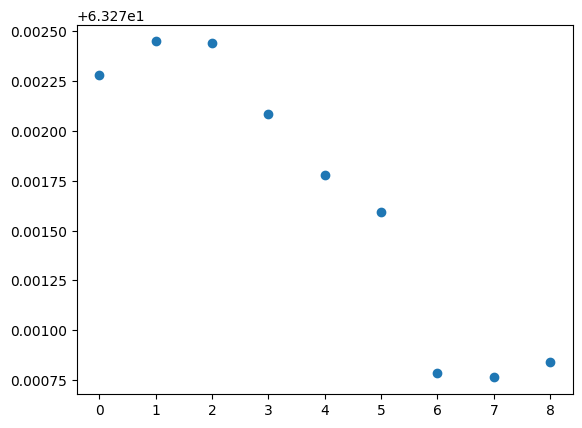

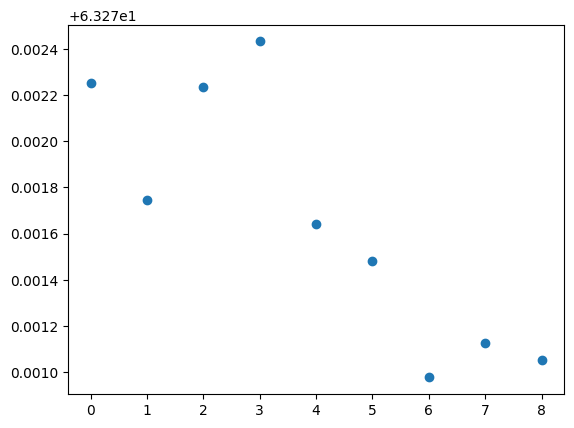

In [5]:
dir = '/shared/rc/llm-degredation/fedllm/barebones/PubMedQA3_triviaqa3_BeaverTails3_500_safe_lora_c9s10_i5_b16a1_l512_r32a64_20260127204846/safelora/Steps[5]_Clients[10]_ISA[False]'
import os
import json
import matplotlib.pyplot as plt
for round in range(30):
    detection_file = os.path.join(dir, f'round_{round}_safelora_gmm.json')
    data = json.load(open(detection_file, 'r'))
    plt.scatter(range(len(data['S_total'])), data['S_total'])
    plt.show()